In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
print("Project root added:", os.path.abspath(".."))

Project root added: d:\myproject


In [2]:
from utils.gemini_resume_parser import parse_resume_file
from utils.gemini_job_parser import parse_job_description
from utils.text_extract import extract_text_from_file
from backend.ats_score_engine import score_resume_against_job
from backend.resume_feedback_engine import (
    generate_internal_feedback,
    generate_candidate_feedback,
)

In [3]:
resume_path = "../data/test_resumes/cvv.docx"

job_text = '''
Python Backend Developer

We are looking for a Python Backend Developer with 3+ years of experience.
Required skills: Python, FastAPI, SQL, Docker, AWS
Preferred skills: REST API, Microservices, Git, Linux
Education: Bachelor's degree in Computer Science or related field
Responsibilities:
- Build scalable backend systems
- Develop REST APIs
- Work with cloud deployment
'''

# job_text = '''
#             Assistant Manager

#             We are looking for an Assistant Manager with 3+ years of experience.
#             Required skills: Leadership, Team Management, Communication, MS Office, Problem-solving
#             Preferred skills: ERP/CRM Tools, Data Analysis, Project Management, Process Improvement
#             Education: Bachelor's degree in Business Administration or related field
#             Responsibilities:
#             Supervise and mentor team members
#             Monitor daily operations and ensure smooth workflow
#             Prepare reports and performance dashboards
#             Coordinate with cross-functional teams
#             Implement process improvements
# '''

In [4]:
resume = parse_resume_file(resume_path)
job = parse_job_description(job_text, prefer_gemini=True)
raw_resume_text = extract_text_from_file(resume_path)

In [5]:
print("=== PARSED RESUME ===")
print(resume.model_dump_json(indent=2))
print("\n=== PARSED JOB ===")
print(job.model_dump_json(indent=2))
print("\n=== RAW RESUME TEXT SAMPLE ===")
print(raw_resume_text[:1500])

=== PARSED RESUME ===
{
  "candidate_name": "MD. SHAHIDUL ISLAM",
  "headline": null,
  "email": "shahidul.islam@email.com",
  "phone": null,
  "location": null,
  "linkedin": null,
  "github": null,
  "portfolio": null,
  "summary": null,
  "total_experience_years": null,
  "skills": {
    "technical": [],
    "tools": [],
    "soft": []
  },
  "education": [],
  "experience": [],
  "projects": [],
  "certifications": [],
  "languages": [],
  "raw_text_used": "fallback_text"
}

=== PARSED JOB ===
{
  "title": "Python Backend Developer",
  "summary": "We are looking for a Python Backend Developer with 3+ years of experience.",
  "required_skills": [
    "fastapi",
    "microservices",
    "python",
    "rest api",
    "sql"
  ],
  "preferred_skills": [],
  "tools": [
    "aws",
    "docker",
    "git",
    "linux"
  ],
  "responsibilities": [
    "we are looking for a python backend developer with 3+ years of experience",
    "required skills python fastapi sql docker aws",
    "prefer

In [6]:
result = score_resume_against_job(
    parsed_resume=resume,
    parsed_job=job,
    resume_raw_text=raw_resume_text,
    job_raw_text=job_text,
)
print(result.model_dump_json(indent=2))

d:\myproject\myproject\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5725.90it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{
  "legacy_ats_score": 81.77,
  "ml_score": 62.8,
  "final_hybrid_score": 67.54,
  "ats_score": 64.66,
  "ranking_score": 54.93,
  "resume_quality_score": 61.13,
  "job_match_score": 67.54,
  "combined_score": 64.66,
  "model_ranking_score": 54.93,
  "score_summary": {
    "score_version": "v3_split_quality_match",
    "resume_quality_score": 61.13,
    "job_match_score": 67.54,
    "combined_score": 64.66,
    "ranking_score": 54.93,
    "legacy_ats_score": 81.77,
    "ml_score": 62.8,
    "model_ranking_score": 54.93
  },
  "match_label": "strong_match",
  "model_name": "Random Forest",
  "parser_mode": "local_fallback",
  "parser_sources": {},
  "class_probabilities": {
    "poor_match": 0.006181,
    "moderate_match": 0.36584,
    "strong_match": 0.627979
  },
  "matched_required_skills": [
    "fastapi",
    "microservices",
    "python",
    "rest api",
    "sql"
  ],
  "missing_required_skills": [],
  "matched_preferred_skills": [
    "rest api",
    "microservices",
    "git",

d:\myproject\myproject\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [7]:
print("ATS Score:", result.ats_score)
print("Ranking Score:", result.ranking_score)
print("Match Label:", result.match_label)

print("\nMatched Required Skills:")
print(result.matched_required_skills)

print("\nMissing Required Skills:")
print(result.missing_required_skills)

print("\nMatched Preferred Skills:")
print(result.matched_preferred_skills)

print("\nMissing Preferred Skills:")
print(result.missing_preferred_skills)

print("\nMatched Keywords:")
print(result.matched_keywords)

print("\nMissing Keywords:")
print(result.missing_keywords)

ATS Score: 64.66
Ranking Score: 54.93
Match Label: strong_match

Matched Required Skills:
['fastapi', 'microservices', 'python', 'rest api', 'sql']

Missing Required Skills:
[]

Matched Preferred Skills:
['rest api', 'microservices', 'git', 'linux']

Missing Preferred Skills:
[]

Matched Keywords:
['fastapi', 'microservices', 'python', 'rest api', 'sql', 'git', 'linux', 'backend', 'developer', 'for', 'with', 'year', 'of', 'experience', 'skill', 'docker', 'aw']

Missing Keywords:
['we', 'are', 'looking', '3+', 'required', 'preferred']


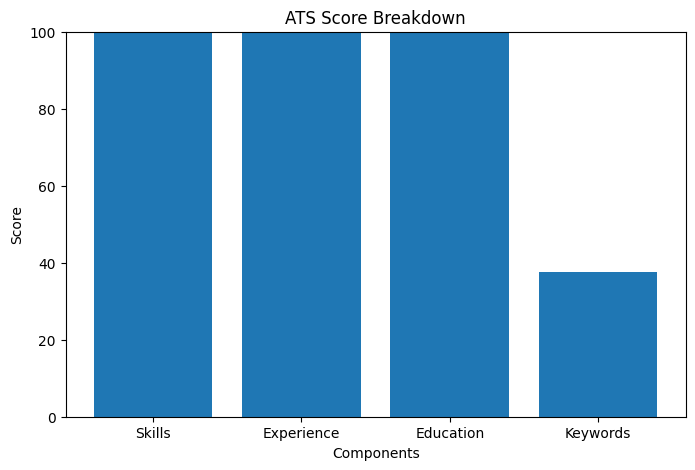

In [8]:
import matplotlib.pyplot as plt

labels = ["Skills", "Experience", "Education", "Keywords"]
scores = [
    result.breakdown["skills"].score,
    result.breakdown["experience"].score,
    result.breakdown["education"].score,
    result.breakdown["keywords"].score,
]

plt.figure(figsize=(8, 5))
plt.bar(labels, scores)
plt.ylim(0, 100)
plt.title("ATS Score Breakdown")
plt.xlabel("Components")
plt.ylabel("Score")
plt.show()

In [9]:
internal_feedback = generate_internal_feedback(resume, job, result)
print(internal_feedback.model_dump_json(indent=2))

{
  "summary": "Candidate classified as strong_match. Resume quality is 61.13, job match is 67.54, and combined score is 64.66. Legacy score is 81.77, ML score is 62.80, and parser mode is local_fallback.",
  "match_label": "strong_match",
  "ats_score": 64.66,
  "resume_quality_score": 61.13,
  "job_match_score": 67.54,
  "combined_score": 64.66,
  "recommendation": "Consider after manual review of missing skills and recent role alignment.",
  "decision_bucket": "review",
  "strengths": [
    "Matched required skills: fastapi, microservices, python, rest api, sql",
    "Matched preferred skills: rest api, microservices, git, linux",
    "Experience alignment appears strong.",
    "Model confidence for strong-match class is high."
  ],
  "risks": [
    "Important role keywords are underrepresented in the resume.",
    "Parser enhancement fell back from Gemini, so some structured fields may be approximate."
  ],
  "accept_reasons": [
    "Required skill evidence found for: fastapi, micr

In [10]:
candidate_feedback = generate_candidate_feedback(resume, job, result)
print(candidate_feedback.model_dump_json(indent=2))

{
  "summary": "Your base resume quality score is 61.13, this job match score is 67.54, and the combined screening score is 64.66.",
  "match_label": "strong_match",
  "ats_score": 64.66,
  "resume_quality_score": 61.13,
  "job_match_score": 67.54,
  "combined_score": 64.66,
  "strengths": [
    "You already match these important skills: fastapi, microservices, python, rest api, sql",
    "You also match these preferred skills: rest api, microservices, git, linux",
    "Your experience level appears well aligned with the role."
  ],
  "improvement_areas": [
    "Add stronger project bullets with outcomes, tools, and measurable impact.",
    "Include more role-specific keywords such as: we, are, looking, 3+, required, preferred"
  ],
  "general_improvement_areas": [
    "Add stronger project bullets with outcomes, tools, and measurable impact."
  ],
  "job_specific_improvement_areas": [
    "Include more role-specific keywords such as: we, are, looking, 3+, required, preferred"
  ],
  "

In [11]:
import json

with open("../data/score/result.json", "w", encoding="utf-8") as f:
    json.dump(result.model_dump(), f, indent=2, ensure_ascii=False)

with open("../data/feedbacks/internal_feedback.json", "w", encoding="utf-8") as f:
    json.dump(internal_feedback.model_dump(), f, indent=2, ensure_ascii=False)

with open("../data/feedbacks/candidate_feedback.json", "w", encoding="utf-8") as f:
    json.dump(candidate_feedback.model_dump(), f, indent=2, ensure_ascii=False)

print("Saved all files")

Saved all files
